<a href="https://colab.research.google.com/github/clementsamson014-coder/ml-lab/blob/main/Ridge_Regression_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# load diabetes dataset
diabetes = load_diabetes()
x = diabetes.data
y = diabetes.target
# train test  split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
# features scaling
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

print("training samsples:", x_train.shape[0])
print("testing samples:", x_test.shape[0])

training samsples: 353
testing samples: 89


In [4]:
linear_model = LinearRegression()
linear_model.fit(x_train, y_train)
y_pred = linear_model.predict(x_test)
print("linear regression")
print("mean squared error:", mean_squared_error(y_test, y_pred))
print("R2 score:", r2_score(y_test, y_pred))


linear regression
mean squared error: 2900.1936284934823
R2 score: 0.45260276297191926


In [7]:
ridge = Ridge()
param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}

ridge_cv = GridSearchCV(ridge, param_grid, cv=5)
ridge_cv.fit(x_train, y_train)

best_ridge = ridge_cv.best_estimator_

y_pred_ridge = best_ridge.predict(x_test)

print("Best Alpha for ridge:", ridge_cv.best_params_['alpha'])
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_ridge))
print("R2 Score:", r2_score(y_test, y_pred_ridge))

Best Alpha for ridge: 10
Mean Squared Error: 2875.7787184218428
R2 Score: 0.4572109567780849


In [8]:
lasso = Lasso(max_iter=1000)

lasso_cv = GridSearchCV(lasso, param_grid, cv=5)
lasso_cv.fit(x_train, y_train)

best_lasso = lasso_cv.best_estimator_
y_pred_lasso = best_lasso.predict(x_test)

print("Best Alpha for Lasso:", lasso_cv.best_params_['alpha'])
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_lasso))
print("R2 Score:", r2_score(y_test, y_pred_lasso))

Best Alpha for Lasso: 1
Mean Squared Error: 2824.568094049959
R2 Score: 0.46687670944102466


In [9]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'Mean Squared Error': [mean_squared_error(y_test, y_pred),
                           mean_squared_error(y_test, y_pred_ridge),
                           mean_squared_error(y_test, y_pred_lasso)],
    'R2 Score': [r2_score(y_test, y_pred),
                 r2_score(y_test, y_pred_ridge),
                 r2_score(y_test, y_pred_lasso)]
})

display(results)


,Model,Mean Squared Error,R2 Score
0,Linear Regression,2900.193628,0.452603
1,Ridge Regression,2875.778718,0.457211
2,Lasso Regression,2824.568094,0.466877


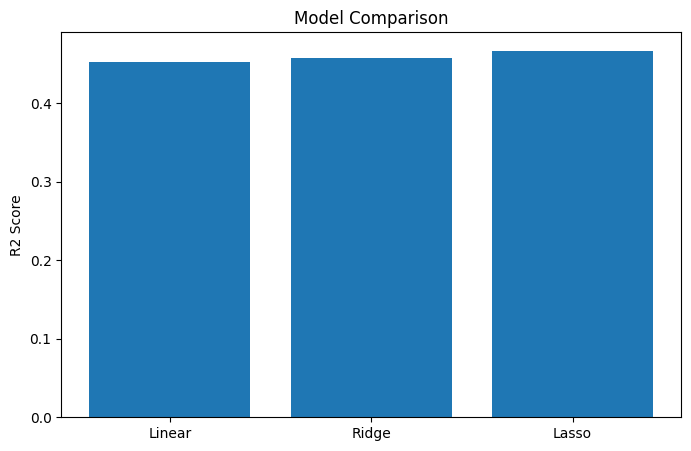

In [12]:
plt.figure(figsize=(8, 5))
models = ['Linear', 'Ridge', 'Lasso']
r2= [
    r2_score(y_test, y_pred),
    r2_score(y_test, y_pred_ridge),
    r2_score(y_test, y_pred_lasso)
]


plt.bar(models,r2)
plt.ylabel('R2 Score')
plt.title('Model Comparison')
plt.show()

